# TPS - NOV 2021

The main objective of this notebook is to learn for myself. I'm implementing different techniques that I learned in the previous TPS. But I cannot guarantee a high scoring notebook! Read on if you like this might help a few.

In [1]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cupy as cp
import pandas as pd
import cudf
import dask_cudf

import gc #to manage ram 
import subprocess

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import optuna

In [2]:
%%time
train = pd.read_csv('../input/tabular-playground-series-nov-2021/train.csv')
test = pd.read_csv('../input/tabular-playground-series-nov-2021/test.csv')

print(train.shape)
print(test.shape)

(600000, 102)
(540000, 101)
CPU times: user 19.5 s, sys: 1.04 s, total: 20.5 s
Wall time: 27.7 s


In [3]:
train.describe()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,...,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,0.306508,2.497590,306.644536,2.647901,0.177850,2.556832,2.699650,2.571593,2.538273,...,2.444471,0.155260,0.059407,0.144932,0.106419,2.547853,2.590159,0.158881,0.123048,0.506010
std,173205.225094,0.522450,1.554018,551.743893,1.544529,0.417488,1.562527,1.564000,1.549361,1.532988,...,1.542509,0.548397,0.119426,0.462015,0.209128,1.558427,1.525091,0.436190,0.264896,0.499964
min,0.000000,-3.797450,-1.223960,-1842.530000,-1.368560,-3.206210,-1.169770,-1.059310,-1.281970,-1.242020,...,-1.217700,-9.761770,-4.666240,-3.101500,-1.276540,-1.584740,-1.254730,-3.993500,-2.783380,0.000000
25%,149999.750000,0.026222,1.186238,43.573400,1.442028,0.019709,1.261038,1.385820,1.333848,1.292163,...,1.214178,0.018904,0.024483,0.017055,0.025461,1.247888,1.348078,0.013536,0.018105,0.000000
50%,299999.500000,0.097788,2.516500,133.626000,2.634130,0.061586,2.590425,2.801255,2.557985,2.475880,...,2.386845,0.068906,0.056649,0.063439,0.062151,2.601940,2.682090,0.058058,0.058471,1.000000
75%,449999.250000,0.397184,3.787630,302.262250,3.907640,0.112712,3.813662,3.996913,3.823450,3.804360,...,3.693872,0.125165,0.088162,0.113114,0.102016,3.820665,3.839520,0.110718,0.104872,1.000000
max,599999.000000,8.781500,6.226720,6119.280000,6.521150,8.265470,6.515070,6.586780,6.258770,6.389670,...,6.573890,18.412800,10.211800,8.623270,3.657220,6.254360,6.145300,10.767000,5.988110,1.000000


In [4]:
test.describe()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
count,5.400000e+05,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,...,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000,540000.000000
mean,8.699995e+05,0.348663,2.618251,263.577730,2.583735,0.211793,2.709543,2.762370,2.479384,2.549483,...,0.072670,2.600771,0.154676,0.056792,0.124517,0.092847,2.442579,2.640276,0.158335,0.140386
std,1.558847e+05,0.566251,1.543507,496.444309,1.529646,0.468154,1.568074,1.586975,1.520741,1.520833,...,0.095479,1.531937,0.546308,0.135927,0.420197,0.191741,1.567684,1.537125,0.430856,0.292759
min,6.000000e+05,-3.628650,-1.260150,-1764.160000,-1.370560,-3.868460,-1.180650,-1.126370,-1.284250,-1.084660,...,-0.610129,-1.438570,-8.970460,-5.565240,-2.958050,-1.907490,-1.939050,-1.232050,-4.537930,-2.305220
25%,7.349998e+05,0.043555,1.326280,27.361175,1.408300,0.028489,1.400490,1.433133,1.278905,1.306570,...,0.025997,1.368090,0.019573,0.019760,0.020277,0.020370,1.117510,1.385690,0.018050,0.021656
50%,8.699995e+05,0.115868,2.657140,115.631000,2.547380,0.072008,2.797510,2.892945,2.456350,2.485895,...,0.059437,2.576965,0.067471,0.051755,0.064928,0.056317,2.458465,2.740695,0.063792,0.061905
75%,1.004999e+06,0.457940,3.884850,245.446250,3.812990,0.125637,3.982830,4.083213,3.694180,3.811365,...,0.094415,3.859483,0.122299,0.083540,0.110353,0.095058,3.737155,3.903460,0.115588,0.108654
max,1.139999e+06,8.666950,6.434070,6098.190000,6.275570,7.915200,6.444200,6.726750,6.339400,6.180310,...,1.966860,6.380110,19.249500,11.484900,8.493580,4.097870,6.210380,6.421930,10.777000,5.414280


In [5]:
train.isna().sum()

id        0
f0        0
f1        0
f2        0
f3        0
         ..
f96       0
f97       0
f98       0
f99       0
target    0
Length: 102, dtype: int64

In [6]:
test.isna().sum()

id     0
f0     0
f1     0
f2     0
f3     0
      ..
f95    0
f96    0
f97    0
f98    0
f99    0
Length: 101, dtype: int64

In [7]:
print(f'Number of missing values in training data: {train.isna().sum().sum()}')
print(f'Number of missing values in testing data: {test.isna().sum().sum()}')

Number of missing values in training data: 0
Number of missing values in testing data: 0


No missing Values! 

In [8]:
Features = [col for col in train.columns if col not in ['id', 'target']]

By initial impressions the data seems to have no categorical features. Let's check if that is the case.

In [9]:
train.drop('id',axis=1,inplace=True)
test.drop('id',axis=1,inplace=True)

Total number of features: 100
Number of categorical features: 0
Number of continuos features: 100


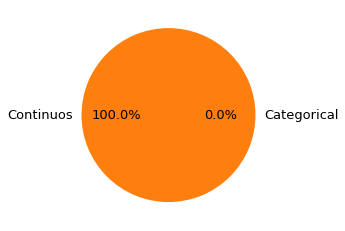

In [10]:
df = pd.concat([train[Features], test[Features]], axis=0)

cat_features = [col for col in Features if df[col].nunique() < 25]
cont_features = [col for col in Features if df[col].nunique() >= 25]

print(f'Total number of features: {len(Features)}')
print(f'Number of categorical features: {len(cat_features)}')
print(f'Number of continuos features: {len(cont_features)}')

plt.pie([len(cat_features), len(cont_features)], 
        labels=['Categorical', 'Continuos'],
        textprops={'fontsize': 13},
        autopct='%1.1f%%')
plt.show()

del df

Yes! We don't have any categorical fearures.

1    303606
0    296394
Name: target, dtype: int64


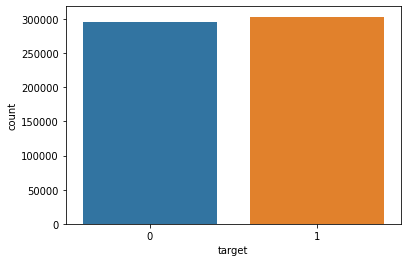

In [11]:
print(train['target'].value_counts())
sns.countplot(x = train['target'],data = train);

Distribution of the target value is balanced :)

In [12]:
#creating a random temperory dataframe to get an idea of how the data is distributed 
#For plotting distributions

np.random.seed(2110)
tmp_train = train.sample(10000)
tmp_test = test.sample(10000)

Feature distribution of features: 


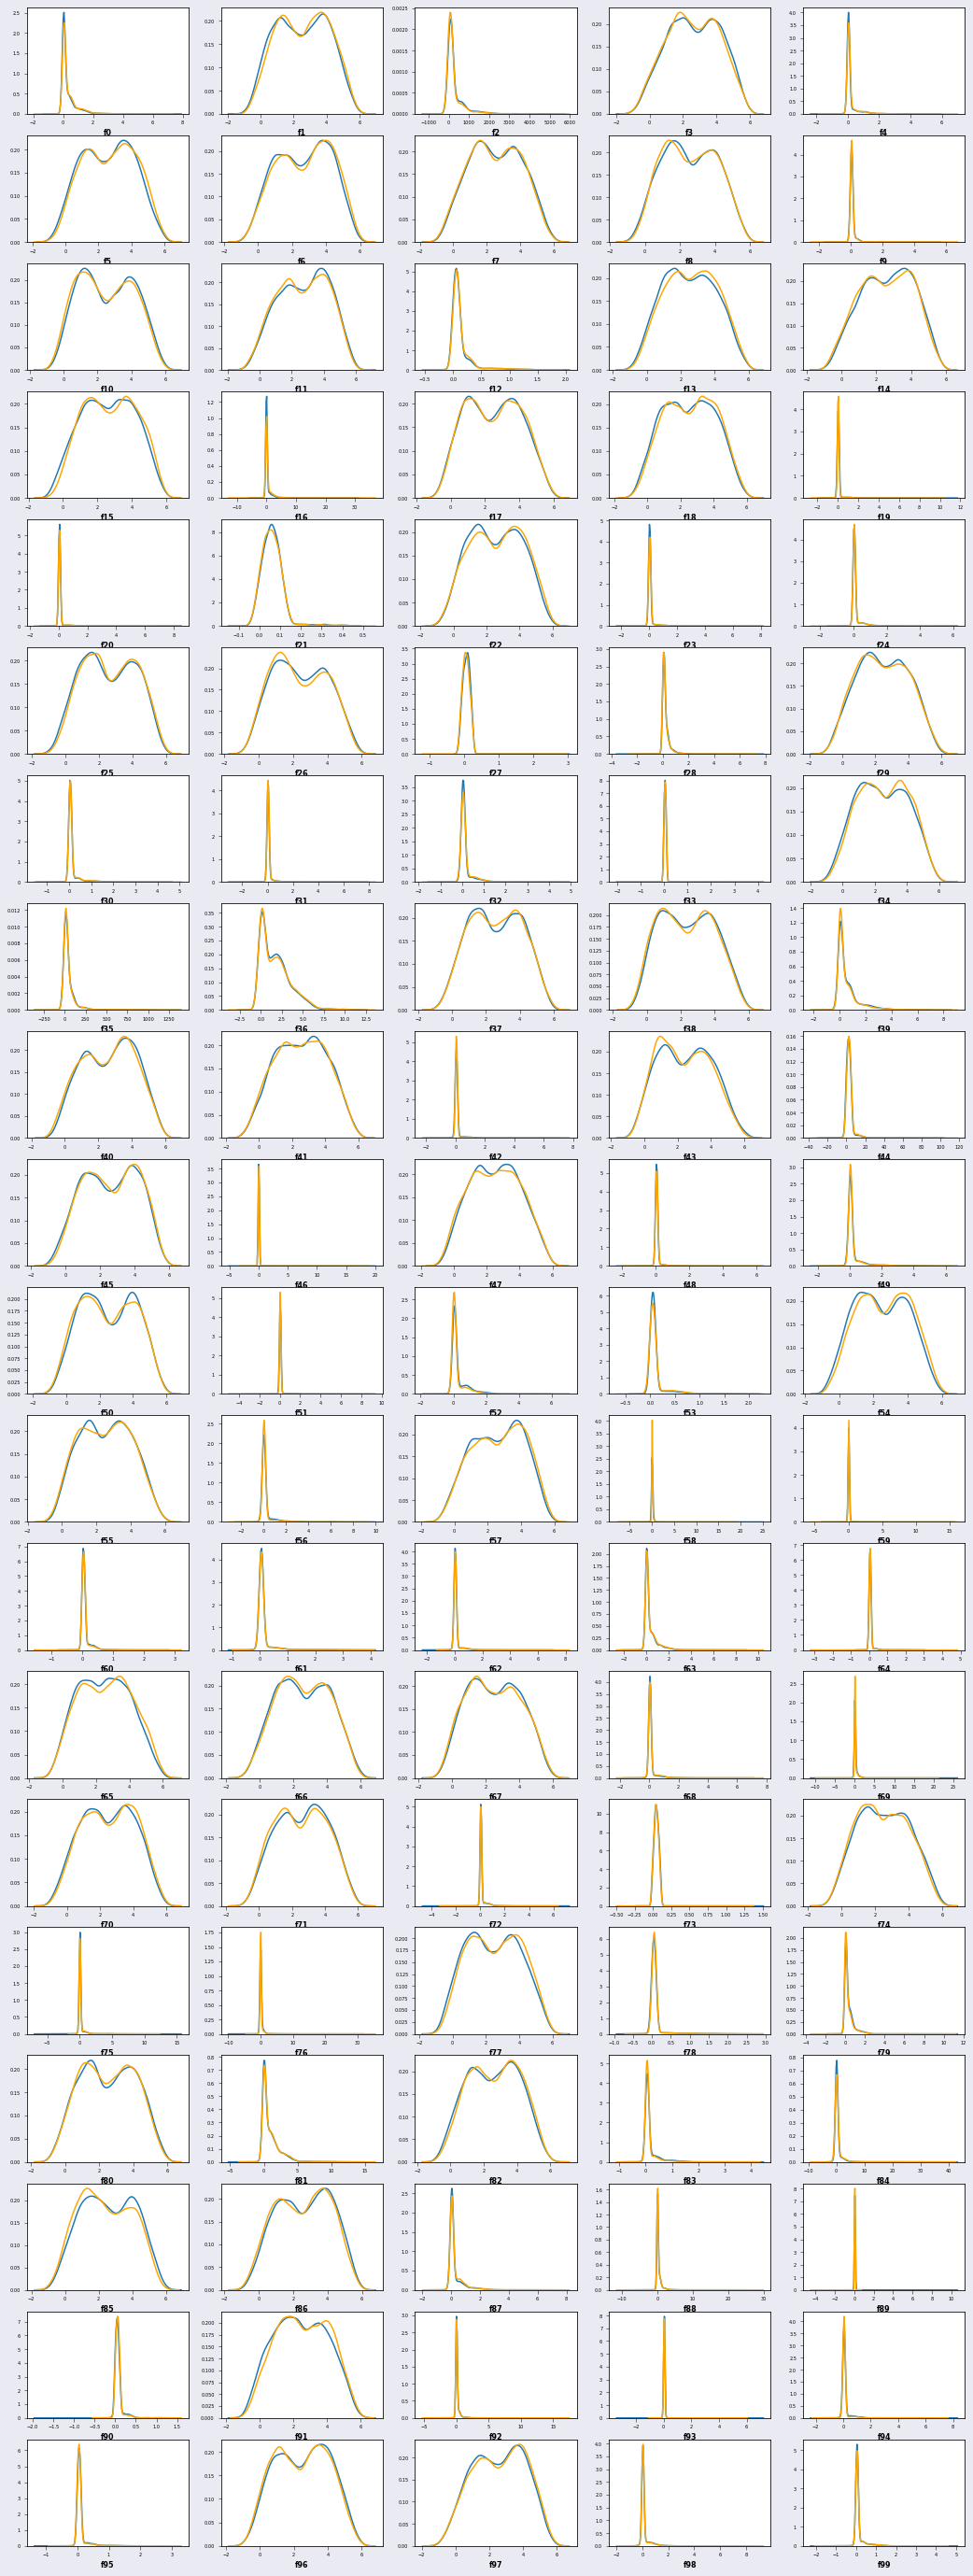

2491

In [13]:
print("Feature distribution of features: ")
ncols = 5
nrows = 20

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 50), facecolor='#EAEAF2')

for r in range(nrows):
    for c in range(ncols):
        col = Features[r*ncols+c]
        sns.kdeplot(x=tmp_train[col], ax=axes[r, c], label='Train data')
        sns.kdeplot(x=tmp_test[col], ax=axes[r, c], color="orange", label='Test data')
        axes[r, c].set_ylabel('')
        axes[r, c].set_xlabel(col, fontsize=8, fontweight='bold')
        axes[r, c].tick_params(labelsize=5, width=0.5)
        axes[r, c].xaxis.offsetText.set_fontsize(4)
        axes[r, c].yaxis.offsetText.set_fontsize(4)
plt.show()

del tmp_train
del tmp_test
gc.collect()

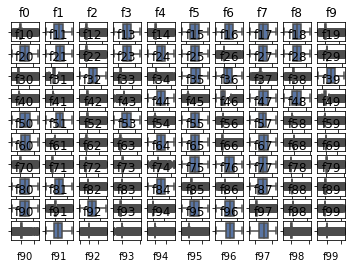

In [14]:
columns = 10
rows = 10
f=0
fig, ax_array = plt.subplots(rows, columns, squeeze=False)
for i,ax_row in enumerate(ax_array):
    for j,axes in enumerate(ax_row):
        axes.set_title('f'+str(f))
        axes.set_yticklabels([])
        axes.set_xticklabels([])
        col = 'f'+str(f)
        sns.set(rc = {'figure.figsize':(30,20)})
        g2 = sns.boxplot(train[col],ax=axes)
        g2.set(ylabel=None)
        g2.set(xticklabels=[])
        g2.set(yticklabels=[])
        f=f+1
plt.show()

In [15]:
train["mean"] = train[Features].mean(axis=1)
train["std"] = train[Features].std(axis=1)
train["min"] = train[Features].min(axis=1)
train["max"] = train[Features].max(axis=1)
train["sum"] = train[Features].sum(axis=1)

test["mean"] = test[Features].mean(axis=1)
test["std"] = test[Features].std(axis=1)
test["min"] = test[Features].min(axis=1)
test["max"] = test[Features].max(axis=1)
test["sum"] = test[Features].sum(axis=1)

Features.extend(['mean', 'std', 'min', 'max', 'sum'])

gc.collect()

318191

In [16]:
print(train.shape)
print(test.shape)

(600000, 106)
(540000, 105)


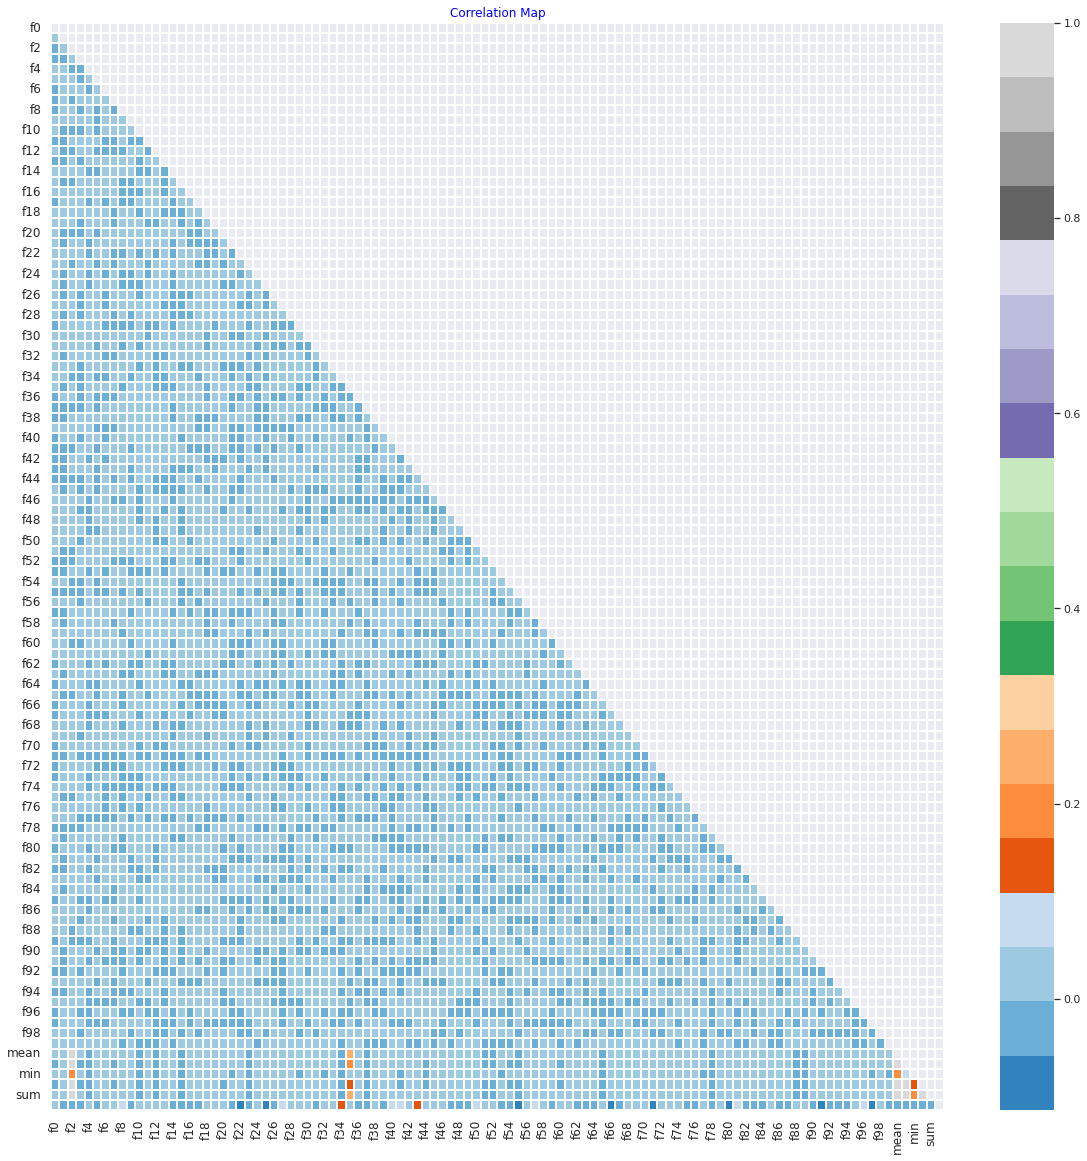

In [17]:
corr = train[Features+['target']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig,ax=plt.subplots(figsize=(20,20))
ax.set_xticklabels(labels=corr.columns,fontsize=12)
ax.set_yticklabels(labels=corr.columns,fontsize=12)
sns.heatmap(corr,mask=mask,cmap='tab20c',linewidth=0.1)
plt.title('Correlation Map',color='blue',fontsize=12)
plt.show()

In [18]:
y = train['target']
train = train.drop(['target'], axis=1)

gc.collect()

36

Adding these features improved the score. We could add more features by performing clustering and PCA(next time, maybe).

Scaling is important!

In [19]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
train[Features] = scaler.fit_transform(train[Features])
test[Features] = scaler.transform(test[Features])

In [20]:
cat_params = {    
    "objective": "CrossEntropy",
    "eval_metric" : "AUC",
    "task_type": "GPU",
    "grow_policy": "SymmetricTree",
    "learning_rate": 0.08,
    "n_estimators":  10_000,
    "random_strength" : 1.0,
    "max_bin": 128,
    "l2_leaf_reg": 0.002550319996478972,
    "max_depth": 4,
    "min_data_in_leaf": 193,
    'verbose': 0
}

The above hyper-parameters used in training are borrowed from the catboost model from the previous TPS(tuned using Optuna).

Let's train our Catboost model.

In [21]:
folds = KFold(n_splits = 5, random_state = 2021, shuffle = True)

predictions = np.zeros(len(test))

for fold, (trn_idx, val_idx) in enumerate(folds.split(train)):
    
    print(f"Fold: {fold}")
    
    X_train, X_test = train.iloc[trn_idx], train.iloc[val_idx]
    y_train, y_test = y.iloc[trn_idx], y.iloc[val_idx]

    model = CatBoostClassifier(**cat_params)
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=400, verbose=False)
    #model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric = 'auc', verbose = 500, early_stopping_rounds = 200)
    
    pred = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, pred)
    print(f" roc_auc_score: {roc}")
    print("-"*50)

Fold: 0
 roc_auc_score: 0.7472855716380209
--------------------------------------------------
Fold: 1
 roc_auc_score: 0.7474543834026508
--------------------------------------------------
Fold: 2
 roc_auc_score: 0.747838623266228
--------------------------------------------------
Fold: 3
 roc_auc_score: 0.7490768723218462
--------------------------------------------------
Fold: 4
 roc_auc_score: 0.7453315695921743
--------------------------------------------------


In [22]:
#lightGBM didn't work 
"""import lightgbm as lgb
lgb_params = {
    'objective': 'binary',
    'n_estimators': 20000,
    'random_state': 42,
    'learning_rate': 8e-3,
    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.4,
    'reg_alpha': 10.0,
    'reg_lambda': 1e-1,
    'min_child_weight': 256,
    'min_child_samples': 20,
    'device': 'gpu',
}used these parameters to get an initial score
params = {
        'objective': 'binary',
        'metric': 'AUC',
        'boosting_type': 'dart', # To improve AUC
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 0.1, 0.9),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 0.1, 0.9),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'device': 'gpu',
        'gpu_platform_id': 0,
        'gpu_device_id': 0,
        'verbose': 0
    }range for optuna to search

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'AUC',
        'boosting_type': 'dart', # To improve AUC
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 0.1, 0.9),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 0.1, 0.9),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'device': 'gpu',
        'gpu_platform_id': 0,
        'gpu_device_id': 0,
        'verbose': 0
    }
    # Learning
    gbm = LightGBM(params, lgb_train, lgb_valid, num_boost_round, verbose_eval, FEATS)
    # Prediction
    y_pred = gbm.predict(valid[FEATS], num_iteration=gbm.best_iteration)
    accuracy = roc_auc_score(y_va, y_pred, labels='ROC curve', average='weighted')
    print('ROC curve:', accuracy)
    ROC_curve(y_va, y_pred)
    # Finish
    print("Operation completed.")
    # Output
    return accuracy"""

'import lightgbm as lgb\nlgb_params = {\n    \'objective\': \'binary\',\n    \'n_estimators\': 20000,\n    \'random_state\': 42,\n    \'learning_rate\': 8e-3,\n    \'subsample\': 0.6,\n    \'subsample_freq\': 1,\n    \'colsample_bytree\': 0.4,\n    \'reg_alpha\': 10.0,\n    \'reg_lambda\': 1e-1,\n    \'min_child_weight\': 256,\n    \'min_child_samples\': 20,\n    \'device\': \'gpu\',\n}used these parameters to get an initial score\nparams = {\n        \'objective\': \'binary\',\n        \'metric\': \'AUC\',\n        \'boosting_type\': \'dart\', # To improve AUC\n        \'lambda_l1\': trial.suggest_loguniform(\'lambda_l1\', 0.1, 0.9),\n        \'lambda_l2\': trial.suggest_loguniform(\'lambda_l2\', 0.1, 0.9),\n        \'num_leaves\': trial.suggest_int(\'num_leaves\', 2, 256),\n        \'feature_fraction\': trial.suggest_uniform(\'feature_fraction\', 0.4, 1.0),\n        \'bagging_fraction\': trial.suggest_uniform(\'bagging_fraction\', 0.4, 1.0),\n        \'bagging_freq\': trial.suggest_i

Using Optuna for hyperparameter tuning for the first time. I am attaching this article to get better insight into Optuna implementation.
https://towardsdatascience.com/hyper-parameter-optimization-with-optuna-4920d5732edf. For Optuna we are required to define an Objective function with the loss function or evaluation metric to optimize. The below code is mostly reusable.

In [23]:
def fit_cat(trial, x_train, y_train, x_test, y_test):
    
    params = {'iterations':trial.suggest_int("iterations", 1000, 100000),
              'od_wait':trial.suggest_int('od_wait', 500, 5000),
              'task_type':"GPU",
              'learning_rate' : trial.suggest_uniform('learning_rate', 0.02 , 0.06),
              'reg_lambda': trial.suggest_loguniform('reg_lambda', 0.30 , 0.33),
              'subsample': trial.suggest_uniform('subsample',0.8,1.0),
              'random_strength': trial.suggest_uniform('random_strength',10,50),
              'depth': trial.suggest_int('depth',1,15),
              'min_data_in_leaf': trial.suggest_int('min_data_in_leaf',1,50),
              'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations',1,15),
              'bootstrap_type':'Poisson'
               }
    
    
    model = CatBoostClassifier(**params)
    model.fit(x_train, y_train,eval_set=[(x_test,y_test)], early_stopping_rounds=150, verbose=False)
    
    y_train_pred = model.predict_proba(x_train)[:,1]
    
    y_test_pred = model.predict_proba(x_test)[:,1]
    y_train_pred = np.clip(y_train_pred, 0.1, None)
    y_test_pred = np.clip(y_test_pred, 0.1, None)
    
    log = {
        "train roc_auc": roc_auc_score(y_train, y_train_pred),
        "valid roc_auc": roc_auc_score(y_test, y_test_pred)
    }
    
    return model, log

In [24]:
def objective(trial):
    roc_auc = 0
    x_train, x_test, y_train, y_test = train_test_split(train, y, test_size=0.30)
    model, log = fit_cat(trial, x_train, y_train, x_test, y_test)
    roc_auc += log['valid roc_auc']
        
    return roc_auc

In [25]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("Number of completed trials: {}".format(len(study.trials)))

[I 2021-11-06 05:30:14,039] A new study created in memory with name: no-name-b055f5a1-95a2-4293-888c-4a380af29bbe
[I 2021-11-06 05:32:51,396] Trial 0 finished with value: 0.7229677324659163 and parameters: {'iterations': 80813, 'od_wait': 1343, 'learning_rate': 0.051634009971590414, 'reg_lambda': 0.32747470528162737, 'subsample': 0.9774367347373808, 'random_strength': 13.301947837139299, 'depth': 14, 'min_data_in_leaf': 42, 'leaf_estimation_iterations': 15}. Best is trial 0 with value: 0.7229677324659163.
[I 2021-11-06 05:33:51,839] Trial 1 finished with value: 0.747612831251781 and parameters: {'iterations': 40518, 'od_wait': 3356, 'learning_rate': 0.036686775443794596, 'reg_lambda': 0.31456975076113775, 'subsample': 0.8017091915579513, 'random_strength': 46.05500615605744, 'depth': 4, 'min_data_in_leaf': 8, 'leaf_estimation_iterations': 8}. Best is trial 1 with value: 0.747612831251781.
[I 2021-11-06 05:36:02,244] Trial 2 finished with value: 0.7481043893543959 and parameters: {'iter

Number of completed trials: 10


In [26]:
print("Best trial:")
trial = study.best_trial
print(trial)

Best trial:
FrozenTrial(number=2, values=[0.7481043893543959], datetime_start=datetime.datetime(2021, 11, 6, 5, 33, 51, 840362), datetime_complete=datetime.datetime(2021, 11, 6, 5, 36, 2, 243649), params={'iterations': 30961, 'od_wait': 930, 'learning_rate': 0.022145477694743048, 'reg_lambda': 0.32254882939451296, 'subsample': 0.8100639715552663, 'random_strength': 49.48124781790108, 'depth': 2, 'min_data_in_leaf': 10, 'leaf_estimation_iterations': 8}, distributions={'iterations': IntUniformDistribution(high=100000, low=1000, step=1), 'od_wait': IntUniformDistribution(high=5000, low=500, step=1), 'learning_rate': UniformDistribution(high=0.06, low=0.02), 'reg_lambda': LogUniformDistribution(high=0.33, low=0.3), 'subsample': UniformDistribution(high=1.0, low=0.8), 'random_strength': UniformDistribution(high=50.0, low=10.0), 'depth': IntUniformDistribution(high=15, low=1, step=1), 'min_data_in_leaf': IntUniformDistribution(high=50, low=1, step=1), 'leaf_estimation_iterations': IntUniform

As the trails are randomly initialised different runs result in different parameters but generally they are fairly close.

In [27]:
optuna.visualization.plot_param_importances(study)

Depth is most important feature followed by learning rate and subsample respectively.

In [28]:
optuna.visualization.plot_optimization_history(study)

In [29]:
optuna.visualization.plot_slice(study, params=['depth', 'learning_rate', 'subsample'])

Lots of plots at our disposal. We can see how score is changing with respect to each parameter. Try tuning a little bit more, it might improve training time if not the final score. There are many more graphs and we can get better search space and we can use pruning to improve training time.

Let's our model with new hyperparameters.

In [30]:
new_params = {
     'iterations': 80203,
     'od_wait': 1765,
     'learning_rate': 0.02010888271017379,
     'reg_lambda': 0.3051769003766273,
     'subsample': 0.9155353016941578,
     'random_strength': 31.905377503941313,
     'depth': 6,
     'min_data_in_leaf': 14,
     'leaf_estimation_iterations': 7,
     'task_type':"GPU",
     'bootstrap_type':'Poisson',
}

In [31]:
folds = KFold(n_splits = 5, random_state = 2021, shuffle = True)

predictions = np.zeros(len(test))

for fold, (trn_idx, val_idx) in enumerate(folds.split(train)):
    
    print(f"Fold: {fold}")
    
    X_train, X_test = train.iloc[trn_idx], train.iloc[val_idx]
    y_train, y_test = y.iloc[trn_idx], y.iloc[val_idx]

    model = CatBoostClassifier(**new_params)
   
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=400, verbose=False)
    
    pred = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, pred)
    print(f" roc_auc_score: {roc}")
    print("-"*50)
    
    predictions += model.predict_proba(test[Features])[:,1] / folds.n_splits 

Fold: 0
 roc_auc_score: 0.748021869025604
--------------------------------------------------
Fold: 1
 roc_auc_score: 0.748033531520623
--------------------------------------------------
Fold: 2
 roc_auc_score: 0.7484038914354801
--------------------------------------------------
Fold: 3
 roc_auc_score: 0.7494409060429212
--------------------------------------------------
Fold: 4
 roc_auc_score: 0.7457751382361721
--------------------------------------------------


In [32]:
sub = pd.read_csv('../input/tabular-playground-series-nov-2021/sample_submission.csv')

In [33]:
sub['target'] = predictions
sub.to_csv('submission.csv', index = 0)
sub

,id,target
0,600000,0.686768
1,600001,0.570396
2,600002,0.814217
3,600003,0.497213
4,600004,0.509056
...,...,...
539995,1139995,0.683582
539996,1139996,0.636658
539997,1139997,0.530621
539998,1139998,0.657080
